In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "salary": [
        18000, 20000, 22000, 24000, 25000, 26000, 28000, 30000,
        32000, 35000, 38000, 40000, 42000, 45000, 48000,
        50000, 52000, 55000, 60000,
        120000, 150000, 200000
    ]
}

df = pd.DataFrame(data)
df

,salary
0,18000
1,20000
2,22000
3,24000
4,25000
5,26000
6,28000
7,30000
8,32000
9,35000


# PART 2 — What YOU must run (step by step)

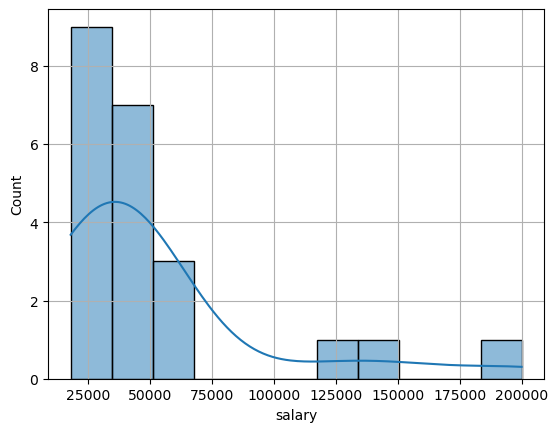

In [7]:
# 1️⃣ Basic graph (this is your baseline)
sns.histplot(df["salary"], kde=True)
plt.grid()
plt.show()


In [5]:
# 2️⃣ Compute EDA metrics (your focus)
stats = df.agg(['var', 'std', 'skew', 'kurtosis']).T
stats

,var,std,skew,kurtosis
salary,2.081922e+09,45628.084311,2.316485,5.101732


# PART 3 — Now I explain EACH metric using THIS graph

1️⃣ Variance (VAR) — Why is it high?

Look at the graph:

Salaries range from 18k → 200k

Values are far apart

👉 High VAR = wide spread

📌 In EDA:

Tells you scale problem

Signals need for transformation

2️⃣ Standard Deviation (STD) — How far values sit from mean

Imagine:

A vertical line at mean salary

Most people are far away from it

👉 Large STD = mean is unreliable

📌 In EDA:

If STD ≈ mean → data is unstable

Median is safer

3️⃣ Skewness — Which side is heavier?

Look at the graph:

■■■■■■■■■▆▅▄▃▂


Long tail on the right

Few very high salaries

👉 Positive skew

📌 In EDA:

Mean > median

Outliers are expected

Don’t remove them blindly

4️⃣ Kurtosis — How extreme are extremes?

Those salaries:

120k

150k

200k

They stretch the tail HARD.

👉 High kurtosis = heavy tails

📌 In EDA:

Extreme values are part of reality

IQR will flag many “outliers”

Removing them = data loss

# PART 4 — Now DO something practical (critical step)

In [9]:
df["salary_log"] = np.log1p(df["salary"])


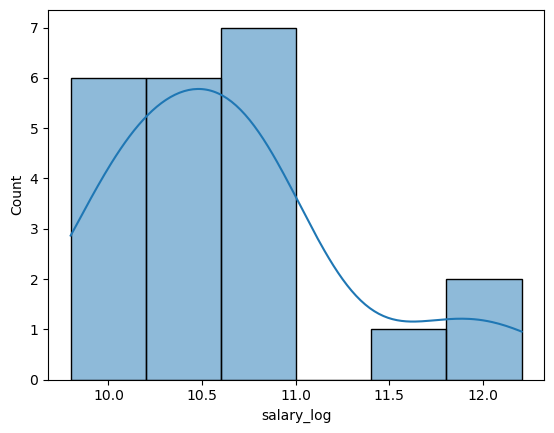

In [10]:
sns.histplot(df["salary_log"], kde=True)
plt.show()


In [13]:
df[["salary", "salary_log"]].agg(
    ['var','std','skew','kurtosis']
).T


,var,std,skew,kurtosis
salary,2.081922e+09,45628.084311,2.316485,5.101732
salary_log,3.977305e-01,0.630659,1.107473,0.966591


# STEP 5 — Compare BEFORE vs AFTER (visually)

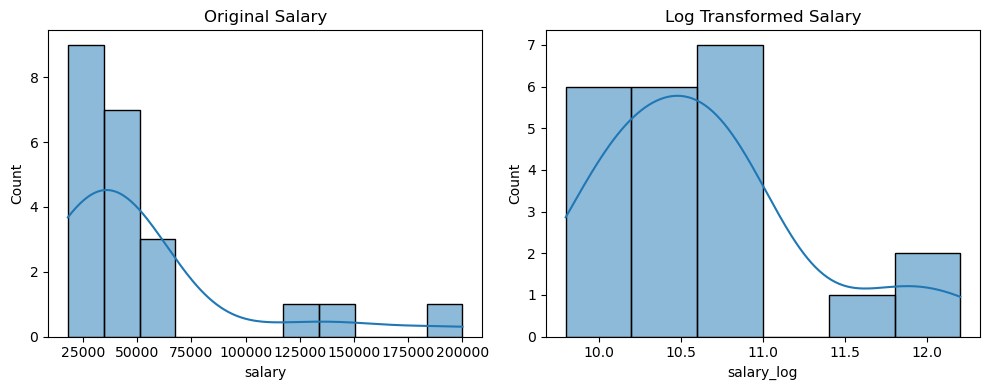

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df["salary"], kde=True)
plt.title("Original Salary")

plt.subplot(1,2,2)
sns.histplot(df["salary_log"], kde=True)
plt.title("Log Transformed Salary")

plt.tight_layout()
plt.show()


# STEP 6 — Boxplot comparison (outliers reality check)

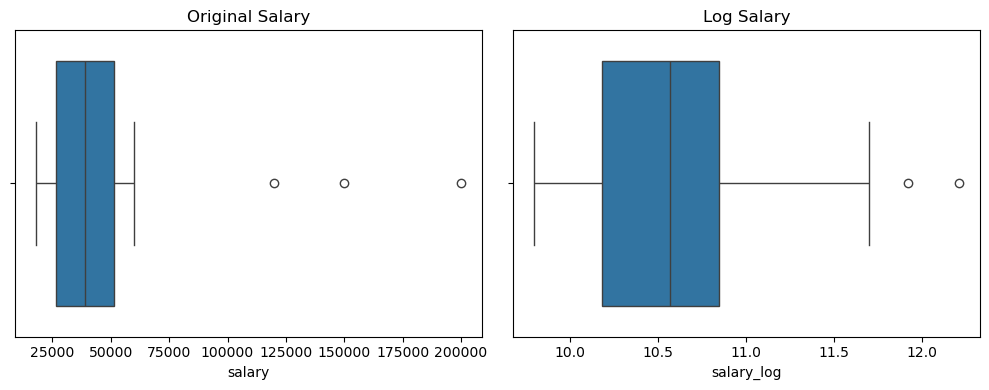

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df["salary"])
plt.title("Original Salary")

plt.subplot(1,2,2)
sns.boxplot(x=df["salary_log"])
plt.title("Log Salary")

plt.tight_layout()
plt.show()
